In [1]:
#Modules
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker
#from matplotlib import rc
#import latex

import random
import math
import scipy 
from scipy.optimize import fsolve
from random import uniform

import astropy
from astropy import modeling
from astropy.convolution import convolve, Gaussian2DKernel

import photutils
from photutils.psf import MoffatPSF

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182.
 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196.
 197. 

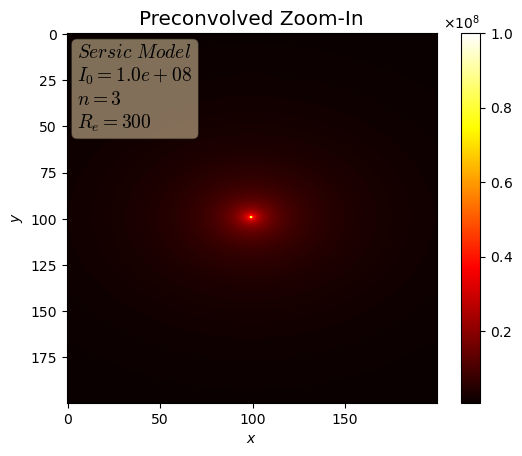

In [3]:
#Copy and pasted elliptical source creation from a previous notebook

#Define the coordinates of the initial mesh grid
xCoords = np.linspace(1,200,200)

#Create the y coordinates
yCoords = np.linspace(1,200,200)

print(xCoords)

#Create a grid of coordinates
xField, yField = np.meshgrid(xCoords, yCoords)

#Define the center of the source
xCenter = 100
yCenter = 100

#Set the eccentricity of the ellipse 
e = 0.75

#Set the angle of rotation (in degrees)
theta = 0

#Compute the angle of rotation in radians
theta = math.radians(theta)
print(theta)

#Solve for the semimajor axis length at all points within the mesh grid

deltaX = xField - xCenter
deltaY = yField - yCenter

a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))

#Set the variables needed to compute the surface brightness profile
n = 3
I_o = 10**8
Beta_n = 2*n - 0.324
R_e = 300

I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))


#Generate a plot

plt.imshow(I, cmap = 'hot')

cbar = plt.colorbar()
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.update_ticks()

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

#Enable the use of latex writing for the plot
#plt.rcParams['text.usetex'] = True
plt.title('Preconvolved Zoom-In')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

text = '\n'.join((
    rf'$Sersic \ Model$',
    rf'$I_0 = {I_o:.1e}$ ',
    rf'$n = {n}$',
    rf'$R_e = {R_e}$'))


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)


plt.text(5, 5, text, fontsize=14, verticalalignment='top', bbox = props)
plt.show()

In [ ]:
#Noise Calculation Process
#We will assume that the default units are in ergs/distance^2/s

#Step 1: Multiply by the exposure time of the image to remove the units of seconds

#Step 2: Remove the units of area in the denominator

#Step 3: Get a power spectra for the galactic source (units of energy might be ideal)
